In [306]:
words = open('names.txt', 'r').read().splitlines()
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [307]:
print(f"Number of names: {len(words)}")
print(f"Smallest name length: {min(len(w) for w in words)}")
print(f"Largest name length: {max(len(w) for w in words)}")

Number of names: 32033
Smallest name length: 2
Largest name length: 15


Firstly, we'll try out the bigram language model. Bigram means two characters at a time, where the model learns to predict what character should following a character

In [308]:
# Lets compute the sliding window showing two neighboring characters:
# Lets also append a starting and ending token
for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        print(ch1, ch2)

. e
e m
m m
m a
a .


Bigram Language Models work by keeping a dictionary and frequency of how often a bigram occurs, and relies on the frequency during inference. So lets make a dictionary:

In [309]:
b = {}
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2)
        b[bigram] = b.get(bigram, 0) + 1 # Checks in the dictionary for the frequency of the bigram, and increments it by 1 on every instance found.

In [310]:
sorted(b.items(), key = lambda kv : kv[1], reverse=True)[:10]

[(('n', '.'), 6763),
 (('a', '.'), 6640),
 (('a', 'n'), 5438),
 (('.', 'a'), 4410),
 (('e', '.'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('.', 'k'), 2963)]

Lots of letters end with $\huge{n}$, $\huge{a}$ and $\huge{e}$. And start with $\huge{a}$, hence those bigram frequencies are the highest. Lets now store these bigrams into a 2D Array using PyTorch

In [311]:
import torch

In [312]:
N = torch.zeros([27, 27], dtype=torch.int32) # 27x27 because there are 26 alphabets, plus the special starting and ending token 26+1=27. For convenience sake, we're representing <S> & <E> with "."

In [313]:
# lets get all the alphabets & then generate a lookup table as a faux tokenizer
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)} # stoi = string to int lookup table
# Manually appending the starting and ending token
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()} #reversing stoi back from ints to strings

In [314]:
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] #ix1 means index = int value of char 1
        ix2 = stoi[ch2] #ix2 means index = int value of char 2
        N[ix1, ix2] += 1 #increment the index for every index found

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

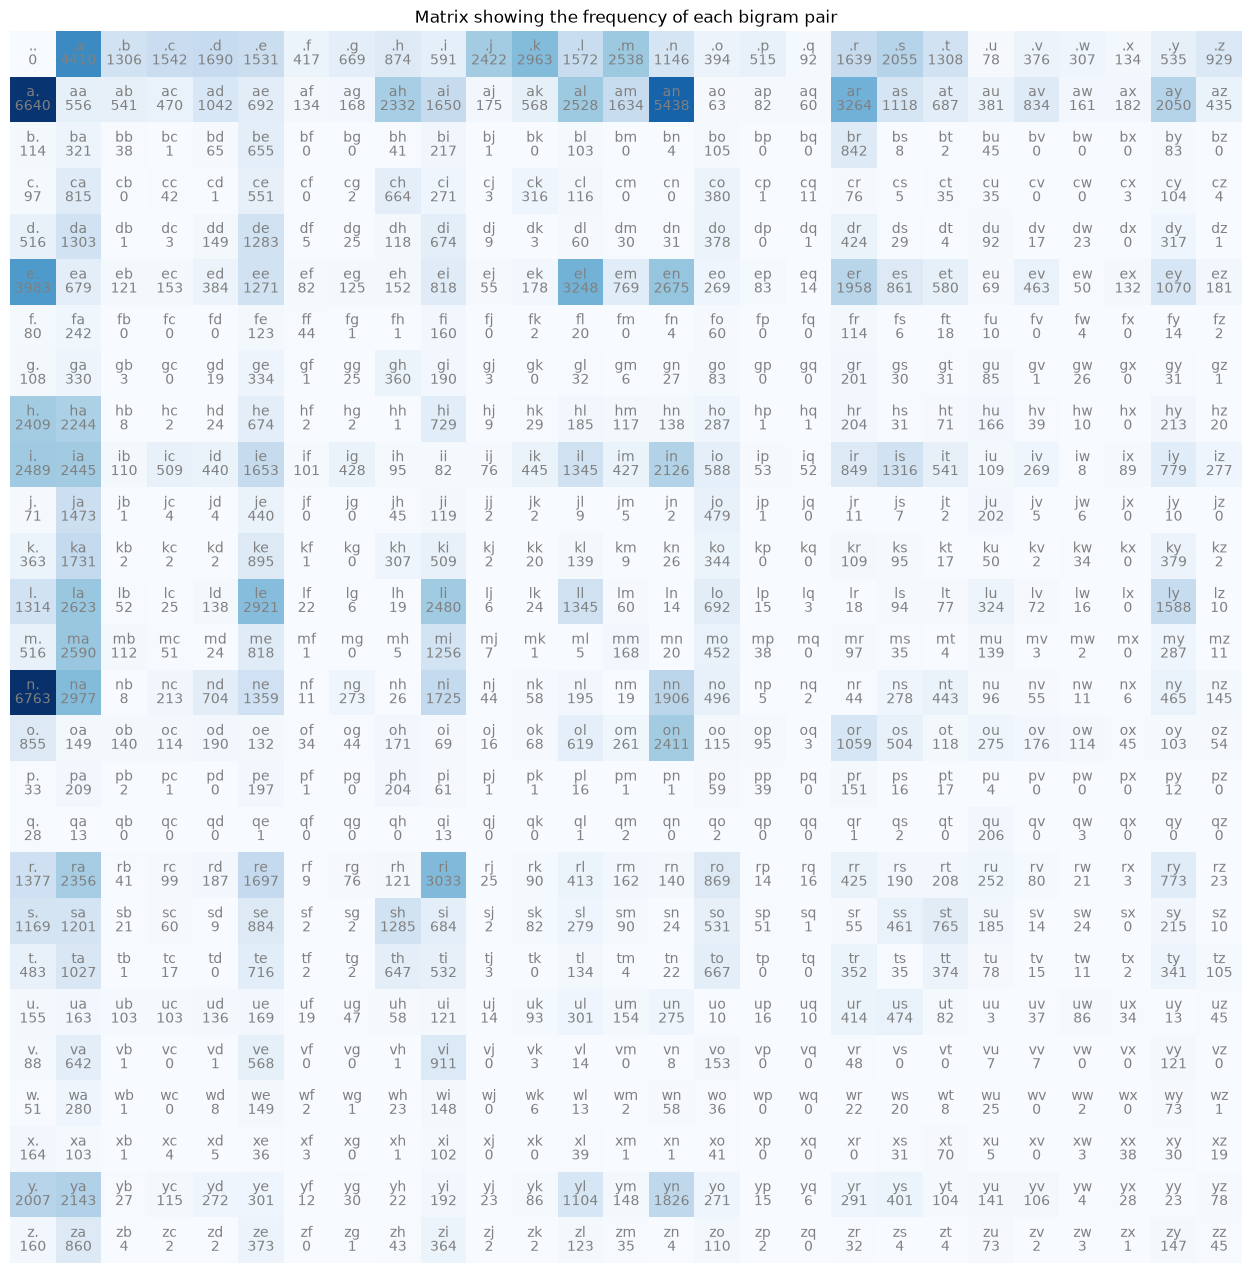

In [315]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color="gray")
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color="gray")
plt.title('Matrix showing the frequency of each bigram pair')
plt.axis('off')

In [316]:
N[0] # this fetches the first row (aka top row)
# Now we convert these values into a probability distribution

p = N[0].float()
p = p / p.sum()
print(f"Probabilities: \n{p}") # converted into probabilities, summing all the values yields 1.0

print(f"Summing the probabilities yields {p.sum()}")

Probabilities: 
tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])
Summing the probabilities yields 1.0


In [317]:
g = torch.Generator().manual_seed(2147483647)
ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # torch.multinomial basically demands a probability distribution, and based on it outputs n number of samples
itos[ix]

'c'

In [318]:
# Lets precompute the probabilities beforehand so that we don't have to calculate it over and over:
P = N.float()
P.shape

torch.Size([27, 27])

In [319]:
P.sum(1, keepdim=True).shape  # This will do the summation row-wise, resulting in a [27, 1] tensor, if we did keepdim = False, it would've squeezed and given [27].

torch.Size([27, 1])

Lets go over broadcasting rules which determine whether an an operation can occur between two tensors:
1. Both tensors must at least have 1 dimension
2. Compare the dimensions of both tensors from right to left. For each pair of dimensions, one of the following must be true:
- They are equal
- One of them must be 1
- Or one of them doesn't exist, in which case it'll be treated as one. 

Example:

${(3, 4)}$ \
${(4,)}$

We compare from right to left so it becomes:

${(3, 4)}$ \
${(\_ ,4)}$

Empty dimension is treated as 1, so:

${(3, 4)}$ \
${(1 ,4)}$

Now, From right to left:

- In ${4, 4}$, they are equal, so condition met.
- In ${3, 1}$, one of them is 1, so condition met.

Therefore they're broadcastable.

Similarly, in case of:

${(27, 27)}$ \
${(27, 1)}$

From right to left column:

- In ${(27, 1)}$, one of them is 1 so condition met.
- In ${(27, 27)}$, both are equal so condition met.


So, $\underline{P = P / P.sum(1, keepdim=True)}$ is $\green{broadcastable}$

In [320]:
P = (N+1).float() # (N+1) written instead of N for model smoothing. Higher the number added, more the probs are smoothed.
P /= P.sum(1, keepdim=True)

In [321]:
P[0].sum() # since the probabilities are normalized now, the sum in each row totals to 1.0

tensor(1.)

Now we know how to fetch values based on their probabilities, so lets write a loop to generate some names

In [322]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(10):
    ix = 0
    out = []
    while True:

        p = P[ix] # Replaced with P to prevent calculating probs over and over.
        # p = N[ix]
        # p = p / p.sum()

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])
        if ix == 0: # since the index 0 represents end token, we break the loop
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


In [323]:
# Let's figure out some way to represent loss, how bad (or good) our model performed. We'll use likelihood, log likelihood in particular.

log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] #ix1 means index = int value of char 1
        ix2 = stoi[ch2] #ix2 means index = int value of char 2
        prob = P[ix1, ix2]
        log_prob = torch.log(prob)
        log_likelihood += log_prob
        n += 1
        # print(f"{ch1}{ch2} : {prob:.4f} : {log_prob:.4f}") # The better the prediction is, the closer log_prob is to 0, the worse it is the more negative it gets.

nll = -log_likelihood
print(f'Log likelihood {log_likelihood}')
print(f'Negative log likelihood {nll}') # making it negative basically makes it a great loss value, since the lowest it can go is 0, and the higher it is, the worse the model performs.
print(f'Average negative log likelihood {nll/n}')

Log likelihood -559951.5625
Negative log likelihood 559951.5625
Average negative log likelihood 2.4543561935424805


All the work above was mostly done through counting probabilities. It's great and all, and we *technically* got a name generator out of it. But lets now do this using neural networks

In [324]:
# Lets make a dataset:

xs, ys = [], [] # xs is inputs, ys is labels

for w in words[:1]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] #ix1 means index = int value of char 1
        ix2 = stoi[ch2] #ix2 means index = int value of char 2
        print(ch1, ch2)
        xs.append(ix1)
        ys.append(ix2)

# Convert to tensors
xs = torch.tensor(xs)
ys = torch.tensor(ys)

. e
e m
m m
m a
a .


In [325]:
print(xs)
print(ys)

tensor([ 0,  5, 13, 13,  1])
tensor([ 5, 13, 13,  1,  0])


We've successfully converted the characters into integers, which is great. But we don't really pass the ints themselves into the neural network. We make use of a thing called one-hot encoding. Where we convert the ints into vectors. For example: assume number of classes are 27 (like in our name generator), onehotting an int 5 would look something like: [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

The reason for not using integers is to prevent the neural nets from assuming some kind of a numerical order. Int for 'a' is 1, and 'b' is 2, but there's nothing two times greater about b than a.

In [326]:
# Onehot encoding:
import torch.nn.functional as F

xenc = F.one_hot(xs, num_classes=27).float() # xenc = x encoded (one-hot), casted to float since neural nets work with that
xenc

tensor([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0.]])

In [327]:
xenc.shape # [5, 27] since '.emma.' yields 5 examples, and each example was onehot encoded with num_classes 27.

torch.Size([5, 27])

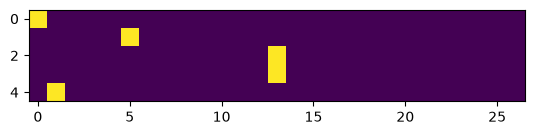

In [328]:
plt.imshow(xenc)

In [329]:
# W = torch.randn((27, 1)) # a column vector of 27 values. this is for one neuron.
W = torch.randn((27, 27), generator=g) # this is 27 neurons, each getting 27 inputs. (no. of inputs, no. of neurons)

xenc @ W

tensor([[ 0.1861,  0.8415, -0.4016, -2.4100,  1.7720, -0.1270,  1.4172, -1.6930,
         -0.3540,  2.2246, -0.4667, -1.1209, -0.0265, -0.9626, -0.4413, -0.8477,
         -0.9468, -0.2705, -1.2589,  1.2130,  0.8729, -0.8185,  0.0348,  0.3700,
          0.0368, -0.0864, -0.2520],
        [-0.8960, -0.7261, -0.0284, -0.3716, -0.7032,  0.0650, -0.6850, -0.4411,
         -0.6407, -2.2924,  0.3534, -0.0294,  2.2914, -1.1258, -1.2025,  0.6428,
          0.7335, -0.9343, -0.5468, -0.4549,  0.4337, -0.9617, -1.1160, -0.0627,
         -0.0830,  0.6072,  0.2820],
        [ 2.0864,  0.5549,  0.4647, -0.6614, -0.2540,  0.0726, -0.0609,  0.8561,
          0.8630, -1.0330,  0.3259,  0.2486,  0.0210, -0.4981, -2.0558,  0.7752,
          1.1227,  0.3588, -1.1587, -0.5996,  3.6454, -0.3754, -1.4451, -0.2279,
          0.3164, -1.3394,  0.2314],
        [ 2.0864,  0.5549,  0.4647, -0.6614, -0.2540,  0.0726, -0.0609,  0.8561,
          0.8630, -1.0330,  0.3259,  0.2486,  0.0210, -0.4981, -2.0558,  0.7752

xenc = [5, 27] \
W = [27, 27] \
in matrix multiplication, the row shape of the first vector is taken, and col shape of the second vector \
So, xenc @ W = [5, 27]

In [330]:
(xenc @ W).shape

torch.Size([5, 27])

lets look at [5, 27]. 5 means the number of inputs, and 27 is the number of neurons. Each one of those values in the dot product shows the firing rate of each neuron for each input. Such as:

In [331]:
(xenc @ W)[3, 13] # This value represents the firing of the 13th neuron for the 3rd input

tensor(-0.4981)

To verify, we can actually check this:

In [332]:
# xenc's 3rd row, and W's 13th column, multipled then summed
(xenc[3] * W[:, 13]).sum()

tensor(-0.4981)

We're making the dumbest most simplest neural network, that consists of an input layer, only a single hidden linear layer, and then the output layer. But wait, output what? We want the NN to ultimately predict the probability of each of the 27 possible characters. But the NN outputs arbitrary scores called logits. To ensure that these values are always positive, we exponentiate them, so negative values become close to 0, and positive values become even more positive. After that we divide the logits by their sum to normalize. So:

In [333]:
logits = xenc @ W # log-counts

# This process is called 'Softmax'
counts = logits.exp() # negative values become close to zero, already positive values become larger positive values.
probs = counts / counts.sum(1, keepdim=True) # think back to why we're using keepdim true, due to broadcasting rules as above.

probs

tensor([[0.0290, 0.0558, 0.0161, 0.0022, 0.1416, 0.0212, 0.0993, 0.0044, 0.0169,
         0.2227, 0.0151, 0.0078, 0.0234, 0.0092, 0.0155, 0.0103, 0.0093, 0.0184,
         0.0068, 0.0810, 0.0576, 0.0106, 0.0249, 0.0349, 0.0250, 0.0221, 0.0187],
        [0.0129, 0.0153, 0.0307, 0.0218, 0.0156, 0.0337, 0.0159, 0.0203, 0.0166,
         0.0032, 0.0450, 0.0307, 0.3123, 0.0102, 0.0095, 0.0601, 0.0658, 0.0124,
         0.0183, 0.0200, 0.0487, 0.0121, 0.0103, 0.0297, 0.0291, 0.0580, 0.0419],
        [0.1079, 0.0233, 0.0213, 0.0069, 0.0104, 0.0144, 0.0126, 0.0315, 0.0318,
         0.0048, 0.0186, 0.0172, 0.0137, 0.0081, 0.0017, 0.0291, 0.0412, 0.0192,
         0.0042, 0.0074, 0.5130, 0.0092, 0.0032, 0.0107, 0.0184, 0.0035, 0.0169],
        [0.1079, 0.0233, 0.0213, 0.0069, 0.0104, 0.0144, 0.0126, 0.0315, 0.0318,
         0.0048, 0.0186, 0.0172, 0.0137, 0.0081, 0.0017, 0.0291, 0.0412, 0.0192,
         0.0042, 0.0074, 0.5130, 0.0092, 0.0032, 0.0107, 0.0184, 0.0035, 0.0169],
        [0.0226, 0.0058,

In [334]:
probs[0].sum() # every row sums to 1, hence valid probabilities

tensor(1.0000)

In [335]:
probs.shape

torch.Size([5, 27])

probs.shape = [5, 27], what does this mean? It means that for each of the 5 examples we're getting 27 probabilities.

In [336]:
nlls = torch.zeros(5)
for i in range(5):
    x = xs[i].item()
    y = ys[i].item()

    print(f"bigram example {i+1}: {itos[x]}, {itos[y]}. Indices ({x},{y})")
    print(f"Input to neural network: {x}")
    print(f"Probabilities of the neural net: {probs[i]}")
    print(f"Actual output: {y}")
    p = probs[i, y]
    print(f"Probability assigned to the actual output: {p}")
    logp = torch.log(p)
    print(f"Log Prob / Log Likelihood {logp}")
    nll = -logp
    print(f"Negative Log Likelihood: {nll}")
    nlls[i] = nll # keeping track
    print(f"------------------------------------------------")

print(f"Average Negative Log Likelihood: {nlls.mean().item()}")

bigram example 1: ., e. Indices (0,5)
Input to neural network: 0
Probabilities of the neural net: tensor([0.0290, 0.0558, 0.0161, 0.0022, 0.1416, 0.0212, 0.0993, 0.0044, 0.0169,
        0.2227, 0.0151, 0.0078, 0.0234, 0.0092, 0.0155, 0.0103, 0.0093, 0.0184,
        0.0068, 0.0810, 0.0576, 0.0106, 0.0249, 0.0349, 0.0250, 0.0221, 0.0187])
Actual output: 5
Probability assigned to the actual output: 0.021203365176916122
Log Prob / Log Likelihood -3.85359525680542
Negative Log Likelihood: 3.85359525680542
------------------------------------------------
bigram example 2: e, m. Indices (5,13)
Input to neural network: 5
Probabilities of the neural net: tensor([0.0129, 0.0153, 0.0307, 0.0218, 0.0156, 0.0337, 0.0159, 0.0203, 0.0166,
        0.0032, 0.0450, 0.0307, 0.3123, 0.0102, 0.0095, 0.0601, 0.0658, 0.0124,
        0.0183, 0.0200, 0.0487, 0.0121, 0.0103, 0.0297, 0.0291, 0.0580, 0.0419])
Actual output: 13
Probability assigned to the actual output: 0.010244332253932953
Log Prob / Log Likeliho

In [337]:
# Lets print them once more for convenience:
print(f"xs: {xs}")
print(f"ys: {ys}")

xs: tensor([ 0,  5, 13, 13,  1])
ys: tensor([ 5, 13, 13,  1,  0])


these are the probabilities for each of the outputs that we should ideally be very high values:

In [338]:
# probs[0, 5], probs[1, 13], probs[2, 13], probs[3, 1], probs[4, 0] # Simplified way of writing it.
probs[torch.arange(5), ys]

tensor([0.0212, 0.0102, 0.0081, 0.0233, 0.0226])

Above probabilities were just.. probabilities. What we want are the negative log likelihood as our loss:

In [339]:
loss = -probs[torch.arange(5), ys].log().mean()
loss

tensor(4.1589)

Now to tie it all together, a training loop would look something like:

In [340]:
xenc = F.one_hot(xs, num_classes=27).float()
W = torch.randn([27, 27], requires_grad=True, generator=g) # no. of inputs (27), no. of neurons (27) hence why W.shape = [27, 27]

In [341]:
# # Forward Pass
# logits = xenc @ W
# counts = logits.exp()
# probs = counts / counts.sum(1, keepdim=True) # softmax

# loss = -probs[torch.arange(5), ys].log().mean()
# loss.item()

# # Backward Pass
# W.grad = None # zero_grad
# loss.backward()

# # Update
# W.data += -0.1 * W.grad

Lets now write it all out one final time.

In [342]:
xs, ys = [], []

for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)

xs = torch.tensor(xs)
ys = torch.tensor(ys)
num = xs.nelement()
print(f"Total Number of Examples: {num}")

Total Number of Examples: 228146


In [343]:
xenc = F.one_hot(xs, num_classes=27).float()
W = torch.randn([27, 27], requires_grad=True, generator=g) # no. of inputs (27), no. of neurons (27) hence why W.shape = [27, 27]

In [346]:
for i in range(100):
    # Foward Pass
    logits = xenc @ W
    counts = logits.exp()
    probs = counts / counts.sum(1, keepdim=True) # softmax
    loss = -probs[torch.arange(num), ys].log().mean() + 0.01*(W**2).mean() # a regularization component (L2-reg), acts similar to model smoothing we did in the counting implementation by (N+1)

    print(f"Step {i+1} | Loss: {loss.item()}")

    # Backward Pass
    W.grad = None # zero grad
    loss.backward()

    # Update
    W.data += -50 * W.grad 

Step 1 | Loss: 2.4918298721313477
Step 2 | Loss: 2.4916298389434814
Step 3 | Loss: 2.4914345741271973
Step 4 | Loss: 2.491243600845337
Step 5 | Loss: 2.4910571575164795
Step 6 | Loss: 2.4908745288848877
Step 7 | Loss: 2.490696668624878
Step 8 | Loss: 2.4905221462249756
Step 9 | Loss: 2.490351676940918
Step 10 | Loss: 2.490185022354126
Step 11 | Loss: 2.4900217056274414
Step 12 | Loss: 2.4898624420166016
Step 13 | Loss: 2.489706039428711
Step 14 | Loss: 2.489553451538086
Step 15 | Loss: 2.4894039630889893
Step 16 | Loss: 2.4892578125
Step 17 | Loss: 2.48911452293396
Step 18 | Loss: 2.4889743328094482
Step 19 | Loss: 2.488837242126465
Step 20 | Loss: 2.4887025356292725
Step 21 | Loss: 2.4885711669921875
Step 22 | Loss: 2.4884424209594727
Step 23 | Loss: 2.4883158206939697
Step 24 | Loss: 2.488192319869995
Step 25 | Loss: 2.4880712032318115
Step 26 | Loss: 2.487952709197998
Step 27 | Loss: 2.4878361225128174
Step 28 | Loss: 2.487722396850586
Step 29 | Loss: 2.4876105785369873
Step 30 | Lo

Not so coincidentally, this loss we're converging on is very close to the one we achieved with counting. And that's expected behavior, since there's not really any new information that we've added to it. We're still working with bigrams.

In [377]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):

    out = []
    ix = 0

    while True:
        # Old
        p = P[ix]

        # New NN
        # xenc = F.one_hot(torch.tensor([ix]), num_classes=27).float()
        # logits = xenc @ W
        # counts = logits.exp()
        # p = counts / counts.sum(1, keepdim=True)

        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
        out.append(itos[ix])

        if ix == 0:
            break

    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.


**Counting Network Output**:

cexze.\
momasurailezitynn.\
konimittain.\
llayn.\
ka.\
da.\
staiyaubrtthrigotai.\
moliellavo.\
ke.\
teda.\

**Neural Network Output**:

cexze.\
momasurailezitynn.\
konimittain.\
llayn.\
ka.\
da.\
staiyaubrtthrigotai.\
moliellavo.\
ke.\
teda.\


Same. Therefore validated.